## Testing implementation of CSMines resops metrics

In [ ]:
import teehr

from pathlib import Path
import shutil
import pandas as pd
import numpy as np

from teehr import Configuration
from dataretrieval import waterdata

# for fetching USGS gage data for gages not in locations table
from teehr.fetching.usgs.usgs import usgs_to_parquet

# Tell Bokeh to output plots in the notebook
from bokeh.io import output_notebook
output_notebook()

### Setup eval

In [ ]:
# define toggle for clearing data
delete_eval = True

In [ ]:
# define eval dir
test_eval_dir = Path(Path.home(), 'temp', 'resops_QC')
if delete_eval:
    if test_eval_dir.exists():
        shutil.rmtree(test_eval_dir)

# create evaluation object
ev = teehr.Evaluation(dir_path=test_eval_dir, create_dir=True)
ev.enable_logging()

In [ ]:
your_api_key = 'thk_cA2mtVDfrVExYDjZmD1mmt11Ut7JK6D6aJK-2zmGQlQ'

ev.download.configure(
    api_key=your_api_key
)

In [ ]:
# define gages used for QC to subset S3
QC_gages = [
    'usgs-01011000',
    'usgs-01013500'
]

# define POR
start_date = pd.to_datetime('2017-10-01')
end_date = pd.to_datetime('2020-09-30')

In [ ]:
ev.download.evaluation_subset(
    start_date=start_date,
    end_date=end_date,
    location_ids=QC_gages,
    primary_configuration_name="usgs_observations",
    secondary_configuration_name="nwm30_retrospective",
)

### Add daily USGS data to test resops metrics

In [ ]:
# add configuration for local data
configuration = Configuration(
    name="usgs_daily",
    timeseries_type="primary",
    description="USGS daily data from NWPS",
)

ev.configurations.add(configuration)

In [ ]:
usgs_gages = ['USGS-01011000', 'USGS-01013500']

df, metadata = waterdata.get_daily(
    monitoring_location_id=usgs_gages,
    parameter_code='00060',
    time='2017-10-01/2020-09-30'
)

In [ ]:
def format_as_teehr(df, gage):
    # filter to gage of interest
    df_filtered = df[df['monitoring_location_id'] == gage]

    # trim to just timeseries data
    df_trimmed = df_filtered[['time','value']]
    df_trimmed.rename(columns={'value':'value', 'time':'value_time'}, inplace=True)

    # add constant fields for teehr
    gage_number = df_filtered['monitoring_location_id'].iloc[0].split('-')[1]
    df_trimmed['location_id'] = f'usgs-{gage_number}'
    df_trimmed['variable_name'] = 'streamflow_daily_mean'
    df_trimmed['unit_name'] = 'm^3/s'
    df_trimmed['member'] = None
    df_trimmed['reference_time'] = None
    df_trimmed['configuration_name'] = 'usgs_daily'

    return df_trimmed

df1_formatted = format_as_teehr(df, usgs_gages[0])
df2_formatted = format_as_teehr(df, usgs_gages[1])

ev.primary_timeseries.load_dataframe(df1_formatted)
ev.primary_timeseries.load_dataframe(df2_formatted)

### Test default (using daily data to compare to Mines result)

#### Using python engine

In [ ]:
CT = teehr.Signatures.CenterOfTiming(primary_field_name='value')
SDoT = teehr.Signatures.StandardDeviationOfTiming(primary_field_name='value')

from teehr import RowLevelCalculatedFields as rcf

df = ev.table('primary_timeseries').filter(
    'configuration_name == "usgs_daily"'
).add_calculated_fields(
    [rcf.WaterYear()]
).aggregate(
    group_by=['location_id', 'water_year'],
    metrics=[CT, SDoT],
    engine='python'
).to_pandas()

sorted_df = df.sort_values(by=['location_id', 'water_year'], ascending=[True, True])
metrics_df = sorted_df.reset_index(drop=True)
metrics_df.head(6)

#### QC check against CSMines test case
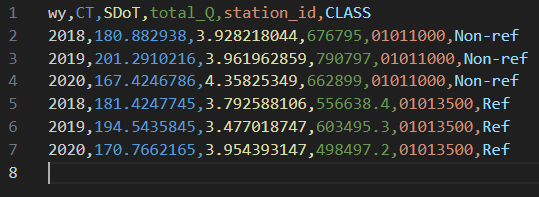

#### Using pyspark engine

In [ ]:
CT = teehr.Signatures.CenterOfTiming(primary_field_name='value')
SDoT = teehr.Signatures.StandardDeviationOfTiming(primary_field_name='value')

from teehr import RowLevelCalculatedFields as rcf

df = ev.table('primary_timeseries').filter(
    'configuration_name == "usgs_daily"'
).add_calculated_fields(
    [rcf.WaterYear()]
).aggregate(
    group_by=['location_id', 'water_year'],
    metrics=[CT, SDoT],
    engine='spark'
).to_pandas()

sorted_df = df.sort_values(by=['location_id', 'water_year'], ascending=[True, True])
metrics_df = sorted_df.reset_index(drop=True)
metrics_df.head(6)

### Test w/ a different missing threshold

In [ ]:
CT = teehr.Signatures.CenterOfTiming(primary_field_name='value', missing_day_threshold=0.99)
SDoT = teehr.Signatures.StandardDeviationOfTiming(primary_field_name='value', missing_day_threshold=0.99)

from teehr import RowLevelCalculatedFields as rcf

df = ev.table('primary_timeseries').filter(
    'configuration_name == "usgs_daily"'
).add_calculated_fields(
    [rcf.WaterYear()]
).aggregate(
    group_by=['location_id', 'water_year'],
    metrics=[CT, SDoT],
).to_pandas()

sorted_df = df.sort_values(by=['location_id', 'water_year'], ascending=[True, True])
metrics_df = sorted_df.reset_index(drop=True)
metrics_df.head(6)

### Test w/o WY in groupby

In [ ]:
CT = teehr.Signatures.CenterOfTiming(primary_field_name='value')
SDoT = teehr.Signatures.StandardDeviationOfTiming(primary_field_name='value')

df = ev.table('primary_timeseries').filter(
    'configuration_name == "usgs_daily"'
).aggregate(
    group_by=['location_id'],
    metrics=[CT, SDoT],
).to_pandas()

sorted_df = df.sort_values(by=['location_id'], ascending=[True])
metrics_df = sorted_df.reset_index(drop=True)
metrics_df.head(6)

### Test on hourly data

#### Test w/ default 

In [ ]:
CT = teehr.Signatures.CenterOfTiming()
SDoT = teehr.Signatures.StandardDeviationOfTiming()

from teehr import RowLevelCalculatedFields as rcf

df = ev.joined_timeseries_view().add_calculated_fields(
    [rcf.WaterYear()]
).aggregate(
    group_by=['primary_location_id', 'water_year'],
    metrics=[CT, SDoT],
).to_pandas()

sorted_df = df.sort_values(by=['primary_location_id', 'water_year'], ascending=[True, True])
metrics_df = sorted_df.reset_index(drop=True)

metrics_df.head(6)

#### Test w/ different threshold

In [ ]:
CT = teehr.Signatures.CenterOfTiming(missing_day_threshold=0.99)
SDoT = teehr.Signatures.StandardDeviationOfTiming(missing_day_threshold=0.99)

from teehr import RowLevelCalculatedFields as rcf

df = ev.joined_timeseries_view().add_calculated_fields(
    [rcf.WaterYear()]
).aggregate(
    group_by=['primary_location_id', 'water_year'],
    metrics=[CT, SDoT],
).to_pandas()

sorted_df = df.sort_values(by=['primary_location_id', 'water_year'], ascending=[True, True])
metrics_df = sorted_df.reset_index(drop=True)

metrics_df.head(6)

All in all, think this is working as intended. I would expect small differences in CT just based on the use of sparse hourly data as opposed to obtaining daily from USGS. 

### Kill Spark

In [ ]:
ev.spark.stop()